In [3]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })

import pandas as pd
from scipy.interpolate import interp1d
import scipy.stats as stats

# load EOS
m_val, r_val, l_val = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
np.random.seed(9167896)


# Check files

In [4]:
df_wide = pd.read_csv("gw_params_wide.dat", sep=" ")
df_narrow = pd.read_csv("gw_params_narrow.dat", sep=" ")

In [3]:
def check_df(df):

    if np.any(np.isnan(df)):
        print("nans in", np.unique(np.where(np.isnan(df))[0]))
    
    if np.any(df["mass_1_source"]> 2.1) or np.any(df["mass_2_source"]> 2.1):
        print("too large masses")
    
    if np.any(df["luminosity_distance"]<10):
        print("too small distances")

check_df(df_narrow)
check_df(df_wide)

# Plots

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

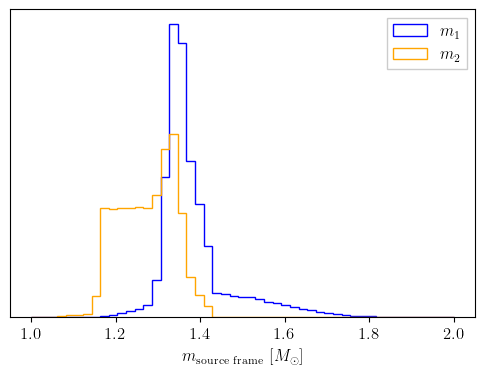

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(1, 2, 50)

ax.hist(df_narrow["mass_1_source"], color="blue", histtype="step", bins=bins, label="$m_1$")
ax.hist(df_narrow["mass_2_source"], color="orange", histtype="step", bins=bins, label="$m_2$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

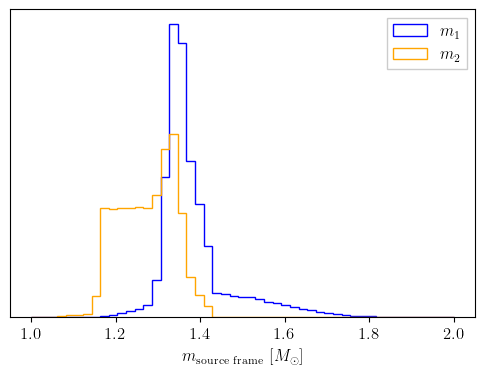

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(1, 2, 50)

ax.hist(df_narrow["mass_1_source"], color="blue", histtype="step", bins=bins, label="$m_1$")
ax.hist(df_narrow["mass_2_source"], color="orange", histtype="step", bins=bins, label="$m_2$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

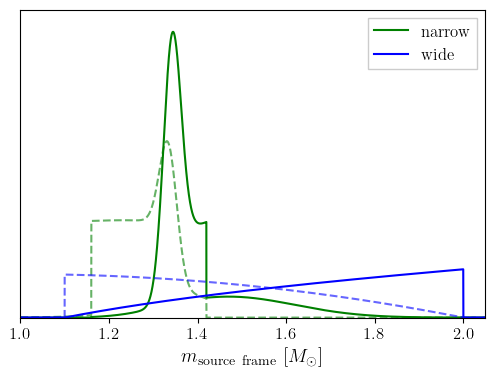

In [3]:
def double_gaussian_pdf(x, params):
    first_peak = np.exp(-0.5 * (x-params["mu_1"])**2 / params["sigma_1"]**2) * 1/np.sqrt(2*np.pi*params["sigma_1"]**2)
    second_peak = np.exp(-0.5 * (x-params["mu_2"])**2 / params["sigma_2"]**2) * 1/np.sqrt(2*np.pi*params["sigma_2"]**2)
    return params["alpha"] * first_peak + (1 - params["alpha"]) * second_peak

def double_gaussian_cdf(x, params):
    first_peak = stats.norm.cdf(x, loc=params["mu_1"], scale=params["sigma_1"])
    second_peak = stats.norm.cdf(x, loc=params["mu_2"], scale=params["sigma_2"])
    return params["alpha"] * first_peak + (1 - params["alpha"]) * second_peak

def uniform_pdf(x, params):
    return np.where((x<params["m_max"]) & (x>params["m_min"]), 1/(params["m_max"]-params["m_min"]), 0)

def uniform_cdf(x, params):
    cdf = (x-params["m_min"]) / (params["m_max"] - params["m_min"])
    cdf = np.maximum(cdf, 0)
    cdf = np.minimum(cdf, 1)
    return cdf

def RecycledBinary(m_arr, params):

    pdf_m1 = double_gaussian_pdf(m_arr, params) * uniform_cdf(m_arr, params) + uniform_pdf(m_arr, params) * double_gaussian_cdf(m_arr, params)
    pdf_m2 = uniform_pdf(m_arr, params) * (1-double_gaussian_cdf(m_arr, params)) + double_gaussian_pdf(m_arr, params) * (1-uniform_cdf(m_arr, params))

    return pdf_m1, pdf_m2


def MassRatioPowerLaw(m_arr, params):

    m_min = params["m_min"]
    m_max = params["m_max"]
    alpha = params["alpha"]

    if alpha != 1:
        normalization_constant = (1+alpha) * (
            m_max**2/2 
            + (1+alpha)/(2*(1-alpha))*m_min**2 
            - (m_min**(alpha+1) * m_max**(1-alpha)) / (1-alpha) 
        )**(-1)

        pdf_m2 = np.where(
            (m_arr >= m_min) & (m_arr <= m_max),
            normalization_constant * m_arr**alpha * (m_max**(1-alpha) - m_arr**(1-alpha)) / (1-alpha),
            0
        )

    else: 
        normalization_constant = (alpha+1) * (
            0.5 *(m_max**2 - m_min**2)
            - m_min**(alpha+1) * np.log(m_max/m_min)
        )**(-1)
        pdf_m2 = np.where(
            (m_arr >= m_min) & (m_arr <= m_max),
            normalization_constant * m_arr**alpha * np.log(m_max/m_arr),
            0
        )
    
    pdf_m1 = np.where(
            (m_arr >= m_min) & (m_arr <= m_max),
            normalization_constant * (m_arr**(1+alpha)-m_min**(1+alpha)) / (alpha+1) * m_arr**(-alpha),
            0
    )

    return pdf_m1, pdf_m2

fig, ax = plt.subplots(1, 1, figsize=(6,4))
m_arr = np.linspace(1, 2.1, 10_000)

narrow_pdf1, narrow_pdf2 = RecycledBinary(m_arr, dict(mu_1=1.34, mu_2=1.47, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3))

wide_pdf1, wide_pdf2 = MassRatioPowerLaw(m_arr, dict(m_min=1.1, m_max=2.0, alpha=2.0, k_coll=1.3))

ax.plot(m_arr, narrow_pdf1, color="green", label="narrow")
ax.plot(m_arr, narrow_pdf2, color="green", alpha=0.6, linestyle='dashed')
ax.plot(m_arr, wide_pdf1, color="blue", label="wide")
ax.plot(m_arr, wide_pdf2, color="blue", alpha=0.6, linestyle='dashed')

ax.legend(framealpha=1, fancybox=False)
ax.set_ylim(0, 12.5)
ax.set_xlim(1.0, 2.05)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]", fontsize=14)

fig.savefig("../../figures/mass_distributions.pdf", dpi=250, bbox_inches="tight")


(10.5, 12.5)

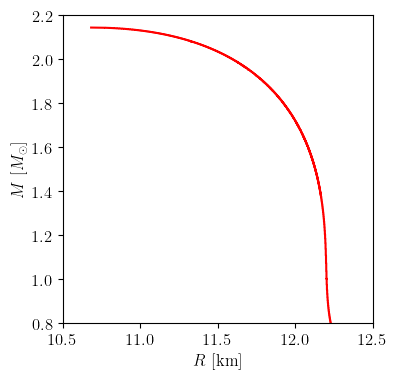

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(r_val, m_val, color="red")

ax.set_ylabel("$M$ [$M_\\odot$]")
ax.set_xlabel("$R$ [km]")
ax.set_ylim((0.8, 2.2))
ax.set_xlim((10.5, 12.5))

# GWToolbox

In [5]:
from astropy.cosmology import Planck18
import astropy.units as u
from astropy.time import Time

from gwtoolbox.tools_earth import set_cosmology, Tools


cosmo = set_cosmology(H0=Planck18.H0.value, Om0=Planck18.Om0, Tcmb=Planck18.Tcmb0.value)
m_mean = 1.35 # Msol
m_scale = 0.3# Msol
m_low = 1.1 # Msol
m_high = 2.1 # Msol
chi_sigma = 0.04
R0=50
tau=3

Toolset = Tools(detector_type='et',
                event_type='nsns',
                population='I',
                cosmos=cosmo,
                det_setup=None,
                new_theta=[R0, tau, m_mean, m_scale, m_low, m_high, chi_sigma]) # population parameters

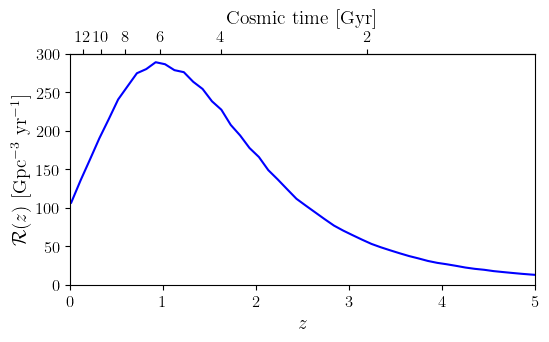

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

ax.plot(Toolset.population_class.zs, Toolset.population_class.Rm, color="blue")

ax.set_xlim((0, 5))
ax.set_ylim((0, 300))
ax.set_ylabel("$\mathcal{R}(z)$ [Gpc$^{-3}$ yr$^{-1}$]", fontsize=14)
ax.set_xlabel("$z$", fontsize=14)

z_grid = np.linspace(0, 6, 1000)
t_grid = Planck18.age(z_grid).to(u.Gyr).value

z_to_t = interp1d(z_grid, t_grid, bounds_error=False)
t_to_z = interp1d(t_grid[::-1], z_grid[::-1], bounds_error=False)

secax = ax.secondary_xaxis('top', functions=(z_to_t, t_to_z))
secax.set_xlabel("Cosmic time [Gyr]", fontsize=14)

fig.savefig("../../figures/rate.pdf", dpi=250, bbox_inches="tight")


In [90]:
def pzm(zm, zf, tau, cosmos):
    # zm is a float, and zf can be a array.
    # zm should not be an array! otherwise it'll mess up with zf
    # NOW zm CAN BE an ARRAY too
    #tm=cosmos.lookback_time(zm).value
    #tf=cosmos.lookback_time(zf).value
    tm=lookback(zm, cosmos)
    tf=lookback(zf, cosmos)
    #TM=np.einsum('i,j->ij',tm,np.ones(len(tf)))
    TM=np.outer(tm, np.ones(len(tf))) # np.outer is equivalent with einsum i,j-->ij, but three times faster
    #TF=np.einsum('i,j->ij',np.ones(len(tm)),tf)
    if np.isscalar(tm):
        TF=tf
    else:
        TF=np.outer(np.ones(len(tm)), tf)
    return 1/tau*np.exp(-(TF-TM)/tau)*np.heaviside(TF-TM,1)#/(1.-np.exp(-tm/tau))

def powerlaw_dtd(zm, zf, cosmos):

    tmin = 1.1 # Gyr

    tm=lookback(zm, cosmos)
    tf=lookback(zf, cosmos)
    TM=np.outer(tm, np.ones(len(tf))) # np.outer is equivalent with einsum i,j-->ij, but three times faster
    if np.isscalar(tm):
        TF=tf
    else:
        TF=np.outer(np.ones(len(tm)), tf)

    return np.where(TF-TM-tmin > 0, (TF - TM)**(-1.9), 0) #np.heaviside(TF - TM - tmin, 1) * (TF - TM)**(-2)




def lookback(z, cosmos):
    if np.isscalar(z)==True:
        zf=np.linspace(0,z,50)
    else:
        zf=np.linspace(0,max(z), 50)
    tf=cosmos.lookback_time(zf).value
    return np.interp(z, zf, tf)

def Psi(z, alpha=2.7, beta=5.6, C=2.9):
    return (1+z)**alpha/(1+((1+z)/C)**beta)

def R(zm, dtd: str, cosmos):
    #ZF=np.logspace(-2, 1., 1000)
    ZF=np.linspace(1e-2,20,1000)
    #ZF=np.linspace(1e-8,max(zm),5000)

    if dtd == "exponential":
        YM= 50 * pzm(zm, ZF, 3, cosmos)*Psi(ZF)*dtovdz(ZF,cosmo)
    elif dtd == "powerlaw":
        YM = 50 * powerlaw_dtd(zm, ZF, cosmos) * Psi(ZF) * dtovdz(ZF, cosmo)

    else:
        raise NotImplementedError

    result=np.trapezoid(YM,ZF)
    if np.isscalar(zm):
        result=result[0]
    else:
        pass
    return result


def dtovdz(z,cosmos):
    #t=cosmos.lookback_time(z).value
    t=lookback(z, cosmos)
    dz=1e-10*np.ones(len(z))
    t_right=lookback(z+dz, cosmos)
    t_left=lookback(z-dz, cosmos)
    #t_right=cosmos.lookback_time(z+dz).value
    #t_left=cosmos.lookback_time(z-dz).value
    return (t_right-t_left)/dz/2.

/tmp/ipykernel_1601333/180132809.py:30: RuntimeWarning: invalid value encountered in power
  return np.where(TF-TM-tmin > 0, (TF - TM)**(-1.9), 0) #np.heaviside(TF - TM - tmin, 1) * (TF - TM)**(-2)


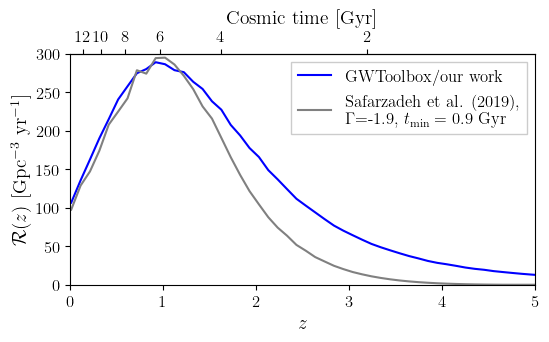

In [93]:
r1 = R(Toolset.population_class.zs, "exponential", cosmo)
r2 = R(Toolset.population_class.zs, "powerlaw", cosmo)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

ax.plot(Toolset.population_class.zs, r1, color="blue", label="GWToolbox/our work")
ax.plot(Toolset.population_class.zs, r2, color="grey", label="Safarzadeh et al. (2019),\n$\\Gamma$=-1.9, $t_{\\mathrm{min}}=0.9$ Gyr")

ax.set_xlim((0, 5))
ax.set_ylim((0, 300))
ax.set_ylabel("$\mathcal{R}(z)$ [Gpc$^{-3}$ yr$^{-1}$]", fontsize=14)
ax.set_xlabel("$z$", fontsize=14)

z_grid = np.linspace(0, 6, 1000)
t_grid = Planck18.age(z_grid).to(u.Gyr).value

z_to_t = interp1d(z_grid, t_grid, bounds_error=False)
t_to_z = interp1d(t_grid[::-1], z_grid[::-1], bounds_error=False)

secax = ax.secondary_xaxis('top', functions=(z_to_t, t_to_z))
secax.set_xlabel("Cosmic time [Gyr]", fontsize=14)

ax.legend(fancybox=False, framealpha=1)

In [59]:
R(Toolset.population_class.zs, "powerlaw", cosmo)

array([ 529.28387811,  964.27220766,  796.00333592, 1251.85171569,
        982.88983788, 2261.69817451, 1396.05695574, 1188.89313022,
       1607.39663999, 1483.86597091, 2071.22393263, 1659.61295031,
       2266.14395116, 1898.7271078 , 2577.171625  , 2023.92305193,
       3344.14737343, 2090.93852817, 2794.37021239, 2142.06094509,
       1762.34573691, 2053.80561298, 1558.96915251, 2088.14883743,
       1597.23793785, 1894.12816021, 1353.99366844, 1208.87376131,
       1506.91712933, 1110.8511235 , 1144.39090269, 1028.97502216,
        896.71328942,  937.63029122,  968.60432771,  881.90012548,
        778.36575431,  794.55227589,  624.55740089,  580.27359108,
        666.33569772,  533.61717954,  527.7823705 ,  494.12395988,
        448.3377459 ,  455.57760841,  452.2950425 ,  427.56829877,
        392.7305286 ,  392.92324308,  325.04561039,  308.91169898,
        287.65403087,  288.05151473,  282.3555189 ,  270.16411486,
        253.44149166,  251.56237832,  215.48344508,  206.70396

In [41]:
np.interp(0, Toolset.population_class.zs, Toolset.population_class.Rm)

np.float64(106.61562891238961)

In [42]:
Toolset.population_class.zs

array([ 0.01      ,  0.11090909,  0.21181818,  0.31272727,  0.41363636,
        0.51454545,  0.61545455,  0.71636364,  0.81727273,  0.91818182,
        1.01909091,  1.12      ,  1.22090909,  1.32181818,  1.42272727,
        1.52363636,  1.62454545,  1.72545455,  1.82636364,  1.92727273,
        2.02818182,  2.12909091,  2.23      ,  2.33090909,  2.43181818,
        2.53272727,  2.63363636,  2.73454545,  2.83545455,  2.93636364,
        3.03727273,  3.13818182,  3.23909091,  3.34      ,  3.44090909,
        3.54181818,  3.64272727,  3.74363636,  3.84454545,  3.94545455,
        4.04636364,  4.14727273,  4.24818182,  4.34909091,  4.45      ,
        4.55090909,  4.65181818,  4.75272727,  4.85363636,  4.95454545,
        5.05545455,  5.15636364,  5.25727273,  5.35818182,  5.45909091,
        5.56      ,  5.66090909,  5.76181818,  5.86272727,  5.96363636,
        6.06454545,  6.16545455,  6.26636364,  6.36727273,  6.46818182,
        6.56909091,  6.67      ,  6.77090909,  6.87181818,  6.97

In [43]:
Toolset.population_class.Rm

array([106.61562891, 135.58005209, 162.65994303, 190.20180401,
       215.03015219, 240.60622511, 257.69829864, 274.6868143 ,
       280.11573454, 288.98924389, 286.37988407, 278.68486747,
       276.07861448, 263.57435619, 254.26911234, 238.25266616,
       227.30977312, 207.56763668, 193.89655828, 177.57792396,
       165.90672948, 148.8467885 , 136.84462777, 124.16832018,
       111.64729537, 102.71606676,  93.97766298,  85.24072209,
        76.82158256,  70.22200118,  64.28885346,  58.51050547,
        53.0030546 ,  48.61793101,  44.66580361,  40.8654016 ,
        37.25813727,  34.20200442,  30.9356482 ,  28.44309891,
        26.62381613,  24.56923175,  22.35790767,  20.6663249 ,
        19.42442679,  17.7191921 ,  16.48929464,  15.31777208,
        14.20437442,  13.23166825,  12.36245253,  11.53451   ,
        10.74647275,  10.05200437,   9.42641607,   8.83016817,
         8.26172342,   7.7443576 ,   7.28614867,   6.84907991,
         6.43174209,   6.05000029,   5.7090445 ,   5.38